# 🛡️ Sentra — Fine-Tuning Pipeline (Google Colab)

Fine-tunes **Qwen/Qwen2.5-1.5B-Instruct** with **Unsloth + QLoRA (4-bit NF4)** + SFTTrainer for phishing detection.

---

## ⚠️ Hardware Requirements

| Runtime | Est. training time | Notes |
|---|---|---|
| T4 GPU (free) | ~5–6 hours | Set in Runtime > Change runtime type > GPU |
| A100 40GB (Pro) | ~1.5–2 hours | Recommended for faster iteration |
| L4 GPU (Pro) | ~2–3 hours | Good middle option |
| **v5e-1 TPU** | **❌ Not compatible** | Unsloth uses CUDA/Triton — TPU not supported |

## 📋 Setup Checklist
1. **Runtime**: `Runtime > Change runtime type > GPU`
2. **Secrets**: Add `HF_TOKEN` and `HF_USER` in the 🔑 Secrets panel (left sidebar)
3. **Run all cells top-to-bottom** — do not skip cells

## 📁 What this notebook does
- Cells 1–6: Environment setup (GPU check, install, Drive mount, auth, config)
- Cells 7–11: Write the training module files to `/content/`
- Cell 12: Run `main.py` — full training pipeline
- Cells 13–14: Display results and download outputs

In [ ]:
# ── Cell 2: GPU / Runtime Check ───────────────────────────────────────────────
import subprocess, sys

result = subprocess.run(["nvidia-smi"], capture_output=True, text=True)
if result.returncode != 0:
    raise RuntimeError(
        "No GPU detected!\n"
        "Go to Runtime > Change runtime type > Hardware accelerator > GPU"
    )

print(result.stdout)

# Check CUDA version for Unsloth compatibility
cuda_result = subprocess.run(["nvcc", "--version"], capture_output=True, text=True)
print(cuda_result.stdout or cuda_result.stderr)

import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available:  {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:             {torch.cuda.get_device_name(0)}")
    print(f"VRAM:            {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Fri Apr  3 01:35:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   34C    P0             57W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
# ── Cell 3: Install Dependencies ──────────────────────────────────────────────
# Unsloth's Colab install auto-selects the correct CUDA wheel
!pip install -q "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install -q --no-deps trl peft accelerate bitsandbytes
!pip install -q transformers datasets scikit-learn matplotlib huggingface_hub python-dotenv
print("\n✓ All packages installed")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 164.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 415.2/415.2 kB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 135.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 124.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.9/224.9 kB 27.6 MB/s eta 0:00:00

✓ All packages installed


In [ ]:
# ── Cell 4: Google Drive Mount + Output Directory ─────────────────────────────
import os

MOUNT_DRIVE = True  # Set False to skip (checkpoints will be lost on disconnect!)

if MOUNT_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    OUTPUT_BASE = "/content/drive/MyDrive/sentra-training"
else:
    OUTPUT_BASE = "/content/sentra-training"
    print("⚠️  Drive not mounted — checkpoints will be lost if runtime disconnects!")

os.makedirs(OUTPUT_BASE, exist_ok=True)
print(f"\n✓ Checkpoints will be saved to: {OUTPUT_BASE}")

Mounted at /content/drive

✓ Checkpoints will be saved to: /content/drive/MyDrive/sentra-training


In [ ]:
# ── Cell 5: HuggingFace Authentication ───────────────────────────────────────
# Option A (recommended): add HF_TOKEN and HF_USER to Colab Secrets panel (🔑 left sidebar)
# Option B (fallback): enter them manually below
import os
from huggingface_hub import login

try:
    from google.colab import userdata
    HF_TOKEN = userdata.get("HF_TOKEN")
    HF_USER  = userdata.get("HF_USER") or ""
    print("✓ Loaded credentials from Colab Secrets")
except Exception:
    import getpass
    print("Colab Secrets not available — entering manually:")
    HF_TOKEN = getpass.getpass("HuggingFace token (write access): ")
    HF_USER  = input("HuggingFace username (or leave blank to skip Hub push): ").strip()

if not HF_TOKEN:
    raise ValueError("HF_TOKEN is required. Add it to Colab Secrets or enter it above.")

os.environ["HF_TOKEN"] = HF_TOKEN
os.environ["HF_USER"]  = HF_USER

login(HF_TOKEN)
print(f"✓ Logged in as: {HF_USER or '(HF_USER not set — Hub push will be skipped)'}")

✓ Loaded credentials from Colab Secrets


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


✓ Logged in as: duyle240820


In [ ]:
# ── Cell 6: Write config.py ───────────────────────────────────────────────────
# Uses Python open() instead of %%writefile so OUTPUT_BASE from Cell 4 is injected.
import os

output_dir = os.path.join(OUTPUT_BASE, "sentra-utoledo-v2.0")

lines = [
    '"""Training configuration — Colab version."""',
    'import os',
    'from huggingface_hub import login',
    '',
    '# ─── Model ────────────────────────────────────────────────────────────────────',
    'BASE_MODEL       = "Qwen/Qwen2.5-1.5B-Instruct"',
    'HF_USER          = os.getenv("HF_USER", "")',
    'PROJECT_NAME     = "sentra-utoledo"',
    'RUN_NAME         = "v2.0"',
    'PROJECT_RUN_NAME = f"{PROJECT_NAME}-{RUN_NAME}"',
    'HUB_MODEL_NAME   = f"{HF_USER}/{PROJECT_RUN_NAME}" if HF_USER else PROJECT_RUN_NAME',
    '',
    '# ─── Data ─────────────────────────────────────────────────────────────────────',
    'DATASETS       = ["SetFit/enron_spam", "ealvaradob/phishing-dataset"]',
    'MAX_SEQ_LENGTH = 2048',
    'MAX_NEW_TOKENS = 128   # reduced for faster Colab eval',
    '',
    '# ─── Quantization ─────────────────────────────────────────────────────────────',
    'QUANT_4_BIT = True',
    'QUANT_8_BIT = False',
    '',
    '# ─── LoRA / QLoRA ─────────────────────────────────────────────────────────────',
    'LORA_R        = 16',
    'LORA_ALPHA    = 32',
    'LORA_DROPOUT  = 0.1',
    'TARGET_MODULES = ["q_proj", "k_proj", "v_proj", "o_proj",',
    '                  "gate_proj", "up_proj", "down_proj"]',
    '',
    '# ─── Training ─────────────────────────────────────────────────────────────────',
    'EPOCHS                      = 3',
    'BATCH_SIZE                  = 8',
    'GRADIENT_ACCUMULATION_STEPS = 2',
    'LEARNING_RATE               = 2e-4',
    'LR_SCHEDULER_TYPE           = "cosine"',
    'WARMUP_RATIO                = 0.03',
    'OPTIMIZER                   = "paged_adamw_32bit"',
    'WEIGHT_DECAY                = 0.01',
    'MAX_GRAD_NORM               = 0.3',
    '',
    '# ─── Admin ────────────────────────────────────────────────────────────────────',
    'LOGGING_STEPS    = 50',
    'SAVE_STEPS       = 500',
    'SAVE_TOTAL_LIMIT = 3',
    f'OUTPUT_DIR       = "{output_dir}"',
    '',
    '# ─── Auth ─────────────────────────────────────────────────────────────────────',
    'def login_huggingface() -> None:',
    '    token = os.environ.get("HF_TOKEN")',
    '    if not token:',
    '        raise EnvironmentError("HF_TOKEN not set.")',
    '    login(token, add_to_git_credential=False)',
    "    print(f\"Logged in as {HF_USER or '(HF_USER not set)'}\")",
]

with open("config.py", "w") as f:
    f.write("\n".join(lines) + "\n")

print("✓ config.py written")
print(f"  OUTPUT_DIR = {output_dir}")

✓ config.py written
  OUTPUT_DIR = /content/drive/MyDrive/sentra-training/sentra-utoledo-v2.0


In [ ]:
%%writefile model.py
"""
Model setup — Unsloth FastLanguageModel loading and LoRA application.

Exports:
    load_model_and_tokenizer() -> tuple[FastLanguageModel, AutoTokenizer]
    apply_lora()               -> PeftModel
"""

from unsloth import FastLanguageModel

import config


# ─── Model + Tokenizer (Unsloth combined load) ────────────────────────────────

def load_model_and_tokenizer():
    """
    Load Qwen2.5-1.5B-Instruct with Unsloth's FastLanguageModel.

    Unsloth fuses attention kernels, rewrites backward passes with Triton,
    and applies smarter gradient checkpointing — no accuracy change vs stock
    HuggingFace, but 2-5x faster throughput and ~40% less GPU memory.

    BitsAndBytes QLoRA (4-bit NF4) is requested via load_in_4bit=True.
    dtype=None lets Unsloth auto-detect bfloat16 for Qwen2.5.

    Returns:
        (model, tokenizer) — tokenizer already has pad_token and padding_side set.
    """
    print("\n" + "=" * 60)
    print("LOADING MODEL (Unsloth FastLanguageModel)")
    print("=" * 60)
    print(f"Base model:     {config.BASE_MODEL}")
    print(f"Max seq length: {config.MAX_SEQ_LENGTH}")
    print(f"4-bit QLoRA:    {config.QUANT_4_BIT}")

    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=config.BASE_MODEL,
        max_seq_length=config.MAX_SEQ_LENGTH,
        load_in_4bit=config.QUANT_4_BIT,
        dtype=None,
        trust_remote_code=True,
    )

    # Causal LM SFT requires right-padding; pad token must exist
    tokenizer.padding_side = "right"
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    footprint_gb = model.get_memory_footprint() / 1e9
    print(f"Memory footprint: {footprint_gb:.2f} GB")
    print(f"Chat template present: {tokenizer.chat_template is not None}")
    print(f"Vocab size: {tokenizer.vocab_size:,}")

    return model, tokenizer


# ─── LoRA (Unsloth optimized adapters) ───────────────────────────────────────

def apply_lora(model):
    """
    Inject LoRA adapters via Unsloth's FastLanguageModel.get_peft_model().

    Unsloth's LoRA uses hand-written Triton kernels for the adapter forward/
    backward passes, giving ~2x speed improvement over stock PEFT on the
    adapter steps. use_gradient_checkpointing="unsloth" enables smarter
    activation recomputation that reduces VRAM by ~30%.

    Args:
        model: Unsloth-loaded base model from load_model_and_tokenizer().

    Returns:
        PeftModel with LoRA adapters applied and frozen base weights.
    """
    print("\n" + "=" * 60)
    print("APPLYING LoRA (Unsloth optimized)")
    print("=" * 60)

    peft_model = FastLanguageModel.get_peft_model(
        model,
        r=config.LORA_R,
        lora_alpha=config.LORA_ALPHA,
        lora_dropout=config.LORA_DROPOUT,
        target_modules=config.TARGET_MODULES,
        use_gradient_checkpointing="unsloth",
        bias="none",
        random_state=42,
    )

    # Print trainable vs total param breakdown
    trainable, total = 0, 0
    for _, p in peft_model.named_parameters():
        total += p.numel()
        if p.requires_grad:
            trainable += p.numel()

    print(f"LoRA rank (r):          {config.LORA_R}")
    print(f"LoRA alpha:             {config.LORA_ALPHA}")
    print(f"LoRA dropout:           {config.LORA_DROPOUT}")
    print(f"Target modules:         {config.TARGET_MODULES}")
    print(f"Gradient checkpointing: unsloth")
    print(f"\nTrainable params: {trainable:,}  ({trainable / total:.2%} of total)")
    print(f"Total params:     {total:,}")

    return peft_model


Writing model.py


In [ ]:
%%writefile data.py
"""
Data pipeline — load, preprocess, merge, split, and format datasets for SFT.

Exports:
    load_datasets()             -> tuple[Dataset, Dataset | None]
    preprocess_and_merge()      -> Dataset
    split_dataset()             -> DatasetDict
    format_for_sft()            -> tuple[DatasetDict, AutoTokenizer]
"""

import json
from datasets import Dataset, DatasetDict, concatenate_datasets, load_dataset
from transformers import AutoTokenizer

import config


# ─── Label constants ──────────────────────────────────────────────────────────

LABEL_LEGITIMATE = 0
LABEL_PHISHING   = 1

# ─── System prompt ────────────────────────────────────────────────────────────

SYSTEM_PROMPT = (
    "You are Sentra, an expert email security analyst. "
    "Analyze the given email and respond with a JSON object containing: "
    '"verdict" (SCAM or LEGITIMATE), "confidence" (0.0-1.0), '
    '"scam_score" (0-100), and "reasoning" (brief explanation).'
)


# ─── Load ─────────────────────────────────────────────────────────────────────

def load_datasets() -> tuple[Dataset, Dataset | None]:
    """
    Load source datasets from HuggingFace and print a summary of each.
    Datasets that use legacy loading scripts (incompatible with datasets>=3.0)
    are skipped with a warning rather than crashing the pipeline.

    Returns:
        (enron_dataset, phishing_dataset_or_None)
    """
    print("\n" + "=" * 60)
    print("LOADING DATASETS")
    print("=" * 60)

    enron_raw = load_dataset("SetFit/enron_spam", split="train")
    _print_dataset_summary("SetFit/enron_spam", enron_raw)

    phishing_raw: Dataset | None = None
    try:
        phishing_raw = load_dataset("ealvaradob/phishing-dataset", split="train")
        _print_dataset_summary("ealvaradob/phishing-dataset", phishing_raw)
    except RuntimeError as exc:
        if "no longer supported" in str(exc):
            print(
                "\n[WARNING] ealvaradob/phishing-dataset uses a legacy loading script "
                "incompatible with datasets>=3.0. Continuing with SetFit/enron_spam only.\n"
                "  To use it: pip install 'datasets<3.0.0' and add trust_remote_code=True."
            )
        else:
            raise

    return enron_raw, phishing_raw


def _print_dataset_summary(name: str, dataset: Dataset) -> None:
    print(f"\n{'─' * 40}")
    print(f"Dataset: {name}")
    print(f"  Size:    {len(dataset):,} rows")
    print(f"  Columns: {dataset.column_names}")
    print(f"  Sample row:\n    {dataset[0]}")

    for col in ("label", "Label", "spam", "is_phishing", "class"):
        if col in dataset.column_names:
            counts: dict[int, int] = {}
            for val in dataset[col]:
                counts[val] = counts.get(val, 0) + 1
            print(f"  Label distribution ({col}): {counts}")
            break


# ─── Preprocess ───────────────────────────────────────────────────────────────

def preprocess_and_merge(
    enron_raw: Dataset,
    phishing_raw: Dataset | None,
) -> Dataset:
    """
    Normalize datasets to {"text": str, "label": int} and merge them.
    phishing_raw may be None if it could not be loaded.

    Label mapping:
        Enron spam: ham (0) -> 0 (legitimate), spam (1) -> 1 (phishing)
        phishing-dataset: maps its positive class -> 1, negative -> 0

    Returns:
        Merged and shuffled Dataset with columns ["text", "label"]
    """
    print("\n" + "=" * 60)
    print("PREPROCESSING & MERGING")
    print("=" * 60)

    enron_clean = _normalize_enron_spam(enron_raw)

    if phishing_raw is not None:
        phishing_clean = _normalize_phishing_dataset(phishing_raw)
        merged = concatenate_datasets([enron_clean, phishing_clean])
    else:
        merged = enron_clean
    merged = merged.shuffle(seed=42)

    counts: dict[int, int] = {}
    for val in merged["label"]:
        counts[val] = counts.get(val, 0) + 1
    print(f"\nMerged dataset: {len(merged):,} rows")
    print(f"  Label distribution: {counts}")
    print(f"  Phishing ratio: {counts.get(1, 0) / len(merged):.1%}")

    return merged


def _normalize_enron_spam(dataset: Dataset) -> Dataset:
    """
    SetFit/enron_spam schema: 'text', 'label' (0=ham, 1=spam).
    Label maps directly: ham=0 (legitimate), spam=1 (phishing).
    """
    def _map(example: dict) -> dict:
        text = (
            example.get("text")
            or example.get("body")
            or example.get("message")
            or ""
        )
        label = int(example.get("label", 0))
        return {"text": str(text).strip(), "label": label}

    normalized = dataset.map(_map, remove_columns=dataset.column_names)
    normalized = normalized.filter(lambda x: len(x["text"]) > 0)
    print(f"\nEnron spam after normalization: {len(normalized):,} rows")
    return normalized


def _normalize_phishing_dataset(dataset: Dataset) -> Dataset:
    """
    ealvaradob/phishing-dataset: inspect and map to {"text", "label"}.
    Positive (phishing) class -> 1, negative (legitimate) -> 0.
    """
    cols = dataset.column_names

    text_col = next(
        (c for c in ("text", "body", "message", "email", "content", "Email Text") if c in cols),
        cols[0],
    )
    label_col = next(
        (c for c in ("label", "Label", "class", "Class", "is_phishing", "spam") if c in cols),
        None,
    )

    print(f"\nPhishing dataset — using text_col='{text_col}', label_col='{label_col}'")

    if label_col:
        unique_labels = list(set(dataset[label_col]))
        print(f"  Unique label values: {unique_labels}")
        positive_values = {"phishing", "spam", "1", 1, True, "true", "Phishing", "Spam"}

        def _map(example: dict) -> dict:
            text = str(example.get(text_col, "")).strip()
            raw  = example.get(label_col)
            label = LABEL_PHISHING if raw in positive_values else LABEL_LEGITIMATE
            return {"text": text, "label": label}
    else:
        print("  No label column found — assuming all rows are phishing (label=1)")

        def _map(example: dict) -> dict:
            text = str(example.get(text_col, "")).strip()
            return {"text": text, "label": LABEL_PHISHING}

    normalized = dataset.map(_map, remove_columns=dataset.column_names)
    normalized = normalized.filter(lambda x: len(x["text"]) > 0)
    print(f"\nPhishing dataset after normalization: {len(normalized):,} rows")
    return normalized


# ─── Split ────────────────────────────────────────────────────────────────────

def split_dataset(merged: Dataset) -> DatasetDict:
    """
    Split merged dataset into 80% train, 10% validation, 10% test.

    Returns:
        DatasetDict with keys "train", "validation", "test"
    """
    print("\n" + "=" * 60)
    print("SPLITTING DATASET")
    print("=" * 60)

    split_1 = merged.train_test_split(test_size=0.2, seed=42)
    split_2 = split_1["test"].train_test_split(test_size=0.5, seed=42)

    dataset_dict = DatasetDict({
        "train":      split_1["train"],
        "validation": split_2["train"],
        "test":       split_2["test"],
    })

    for split_name, ds in dataset_dict.items():
        counts: dict[int, int] = {}
        for val in ds["label"]:
            counts[val] = counts.get(val, 0) + 1
        print(f"  {split_name:12s}: {len(ds):>7,} rows  |  {counts}")

    return dataset_dict


# ─── SFT formatting ───────────────────────────────────────────────────────────

def _label_to_reasoning(label: int) -> str:
    """Generate template-based synthetic reasoning from binary label."""
    if label == LABEL_PHISHING:
        return (
            "This email exhibits characteristics consistent with phishing: "
            "urgent language, suspicious requests, or deceptive framing designed "
            "to manipulate the recipient into revealing credentials or clicking malicious links."
        )
    return (
        "This email appears to be legitimate: normal business communication "
        "without suspicious urgency, unusual credential requests, or deceptive elements."
    )


def _format_instruction_response(example: dict) -> dict:
    """
    Transform {text, label} -> {prompt, response, label} SFT format.
    """
    label      = int(example["label"])
    verdict    = "SCAM" if label == LABEL_PHISHING else "LEGITIMATE"
    confidence = 0.95 if label == LABEL_PHISHING else 0.92
    scam_score = 88.0 if label == LABEL_PHISHING else 8.0
    reasoning  = _label_to_reasoning(label)

    response_json = json.dumps({
        "verdict":    verdict,
        "confidence": confidence,
        "scam_score": scam_score,
        "reasoning":  reasoning,
    })

    return {
        "prompt":   example["text"],
        "response": response_json,
        "label":    label,
    }


def format_for_sft(
    dataset_dict: DatasetDict,
    tokenizer: AutoTokenizer,
) -> tuple[DatasetDict, AutoTokenizer]:
    """
    Transform dataset to SFT format using the Qwen2.5 chat template.

    Returns:
        (formatted_DatasetDict, tokenizer)
        formatted_DatasetDict columns: "text" (chat string), "label" (for eval)
    """
    print("\n" + "=" * 60)
    print("FORMATTING FOR SFT")
    print("=" * 60)

    if tokenizer.chat_template is None:
        raise ValueError(
            "Tokenizer has no chat_template. "
            "Ensure you loaded from Qwen/Qwen2.5-1.5B-Instruct."
        )

    def _apply_chat_template(example: dict) -> dict:
        messages = [
            {"role": "system",    "content": SYSTEM_PROMPT},
            {"role": "user",      "content": example["prompt"]},
            {"role": "assistant", "content": example["response"]},
        ]
        text = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=False,
        )
        return {"text": text, "label": example["label"]}

    formatted = dataset_dict.map(
        _format_instruction_response,
        remove_columns=["text"],
        desc="Building instruction-response pairs",
    )
    formatted = formatted.map(
        _apply_chat_template,
        remove_columns=["prompt", "response"],
        desc="Applying Qwen chat template",
    )

    for split_name, ds in formatted.items():
        print(f"  {split_name:12s}: {len(ds):>7,} rows  |  columns: {ds.column_names}")
        sample_text = ds[0]["text"][:200].replace("\n", "\\n")
        print(f"  Sample (truncated): {sample_text}...")

    return formatted, tokenizer


Writing data.py


In [ ]:
%%writefile train.py
"""
Training — SFTTrainer setup, training loop, and Hub push.

Exports:
    build_trainer()  -> SFTTrainer
    run_training()   -> SFTTrainer
    push_to_hub()    -> None
"""

import torch
from transformers import AutoTokenizer
from datasets import DatasetDict
from peft import PeftModel
from trl import SFTTrainer, SFTConfig

import config


# ─── Trainer setup ────────────────────────────────────────────────────────────

def build_trainer(
    model: PeftModel,
    formatted_datasets: DatasetDict,
    tokenizer: AutoTokenizer,
) -> SFTTrainer:
    """
    Configure SFTConfig and build the TRL SFTTrainer.

    SFTTrainer handles causal LM language modeling loss (cross-entropy on
    all tokens in the 'text' column produced by apply_chat_template).
    Evaluation during training uses eval_loss as the checkpoint metric.

    Args:
        model:              LoRA-wrapped PeftModel.
        formatted_datasets: DatasetDict with "train" and "validation" splits.
        tokenizer:          Qwen AutoTokenizer.

    Returns:
        Configured SFTTrainer, ready to call .train() on.
    """
    print("\n" + "=" * 60)
    print("BUILDING TRAINER")
    print("=" * 60)

    use_cuda = torch.cuda.is_available()

    sft_config = SFTConfig(
        output_dir=config.OUTPUT_DIR,
        num_train_epochs=config.EPOCHS,
        per_device_train_batch_size=config.BATCH_SIZE,
        per_device_eval_batch_size=config.BATCH_SIZE,
        gradient_accumulation_steps=config.GRADIENT_ACCUMULATION_STEPS,
        optim=config.OPTIMIZER,
        learning_rate=config.LEARNING_RATE,
        weight_decay=config.WEIGHT_DECAY,
        lr_scheduler_type=config.LR_SCHEDULER_TYPE,
        warmup_ratio=config.WARMUP_RATIO,
        max_grad_norm=config.MAX_GRAD_NORM,
        fp16=False,
        bf16=True,
        logging_steps=config.LOGGING_STEPS,
        eval_strategy="steps",
        eval_steps=config.SAVE_STEPS,
        save_strategy="steps",
        save_steps=config.SAVE_STEPS,
        save_total_limit=config.SAVE_TOTAL_LIMIT,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        report_to="none",
        run_name=config.RUN_NAME,
        push_to_hub=bool(config.HF_USER),
        hub_model_id=config.HUB_MODEL_NAME if config.HF_USER else None,
        hub_strategy="every_save",
        hub_private_repo=True,
        dataloader_pin_memory=use_cuda,
        # SFT-specific
        max_length=config.MAX_SEQ_LENGTH,
        dataset_text_field="text",
        packing=True,
    )

    trainer = SFTTrainer(
        model=model,
        args=sft_config,
        train_dataset=formatted_datasets["train"],
        eval_dataset=formatted_datasets["validation"],
        processing_class=tokenizer,
    )

    print(f"Training samples:   {len(formatted_datasets['train']):,}")
    print(f"Validation samples: {len(formatted_datasets['validation']):,}")
    print(f"Epochs:             {config.EPOCHS}")
    print(f"Batch size:         {config.BATCH_SIZE}  (grad accum: {config.GRADIENT_ACCUMULATION_STEPS})")
    print(f"Effective batch:    {config.BATCH_SIZE * config.GRADIENT_ACCUMULATION_STEPS}")
    print(f"Learning rate:      {config.LEARNING_RATE}")
    print(f"Optimizer:          {config.OPTIMIZER}")
    print(f"Max seq length:     {config.MAX_SEQ_LENGTH}")
    print(f"Output dir:         {config.OUTPUT_DIR}")

    return trainer


# ─── Training loop ────────────────────────────────────────────────────────────

def run_training(trainer: SFTTrainer) -> SFTTrainer:
    """
    Run trainer.train().

    Returns:
        The same SFTTrainer (now with training state populated).
    """
    print("\n" + "=" * 60)
    print("TRAINING")
    print("=" * 60)

    trainer.train()

    print("\nTraining complete.")
    return trainer


# ─── Hub push ─────────────────────────────────────────────────────────────────

def push_to_hub(trainer: SFTTrainer, tokenizer: AutoTokenizer) -> None:
    """
    Push the fine-tuned model and tokenizer to HuggingFace Hub.
    """
    if not config.HF_USER:
        print("HF_USER not set in config — skipping Hub push.")
        return

    print("\n" + "=" * 60)
    print("PUSHING TO HUB")
    print("=" * 60)
    print(f"Destination: {config.HUB_MODEL_NAME}")

    trainer.model.push_to_hub(config.HUB_MODEL_NAME, private=True)
    tokenizer.push_to_hub(config.HUB_MODEL_NAME, private=True)

    print(f"Model pushed to: https://huggingface.co/{config.HUB_MODEL_NAME}")


Writing train.py


In [ ]:
%%writefile evaluation.py
"""
Evaluation — generate-based verdict accuracy, per-sample Tester class,
and confusion matrix.

Exports:
    run_evaluation()        -> dict
    Tester                  (class)
    plot_confusion_matrix() -> None
"""

import json
import re
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from transformers import AutoTokenizer
from datasets import Dataset

import config
import data as data_module

GREEN = "\033[92m"
RED   = "\033[91m"
RESET = "\033[0m"


# ─── JSON verdict parsing ─────────────────────────────────────────────────────

def _parse_verdict(output_text: str) -> str | None:
    """
    Extract verdict from model-generated text.
    Tries JSON parsing first; falls back to keyword search.

    Returns:
        "SCAM", "LEGITIMATE", or None on parse failure.
    """
    try:
        json_match = re.search(r'\{[^{}]*"verdict"[^{}]*\}', output_text, re.DOTALL)
        if json_match:
            parsed  = json.loads(json_match.group())
            verdict = str(parsed.get("verdict", "")).upper().strip()
            if verdict in ("SCAM", "LEGITIMATE"):
                return verdict
    except (json.JSONDecodeError, AttributeError, ValueError):
        pass

    upper = output_text.upper()
    if "SCAM" in upper:
        return "SCAM"
    if "LEGITIMATE" in upper:
        return "LEGITIMATE"
    return None


def _verdict_to_label(verdict: str | None) -> int:
    return 1 if verdict == "SCAM" else 0


# ─── Full test-set evaluation ─────────────────────────────────────────────────

def run_evaluation(trainer, test_dataset: Dataset) -> dict:
    """..."""
    print("\n" + "=" * 60)
    print("EVALUATION — TEST SET (eval_loss)")
    print("=" * 60)

    # packing=True uses Unsloth's collator which expects pre-tokenized input_ids.
    # SFTTrainer only tokenizes datasets passed at _init_ time, so a dataset
    # passed directly to evaluate() must be tokenized manually first.
    tokenizer = trainer.processing_class

    def _tokenize(examples):
        out = tokenizer(
            examples["text"],
            truncation=True,
            max_length=config.MAX_SEQ_LENGTH,
            padding=False,
        )
        out["labels"] = out["input_ids"].copy()
        return out

    tokenized_test = test_dataset.map(
        _tokenize,
        batched=True,
        remove_columns=test_dataset.column_names,
        desc="Tokenizing test set",
    )

    metrics = trainer.evaluate(eval_dataset=tokenized_test)


# ─── Per-sample Tester ────────────────────────────────────────────────────────

class Tester:
    """
    Generate text predictions on a subset of the test set, parse JSON verdicts,
    and report verdict accuracy with a confusion matrix.
    """

    def __init__(
        self,
        model,
        tokenizer: AutoTokenizer,
        test_dataset: Dataset,
        size: int = 100,
    ) -> None:
        self.model          = model
        self.tokenizer      = tokenizer
        self.size           = min(size, len(test_dataset))
        self.test_dataset   = test_dataset.select(range(self.size))
        self.predictions: list[int] = []
        self.truths: list[int]      = []
        self.parse_failures = 0

    def _generate_one(self, chat_text: str) -> str:
        """
        Strip the assistant turn from the chat string, generate, and decode.

        Returns:
            Decoded model output (assistant response only).
        """
        assistant_marker = "<|im_start|>assistant"
        idx = chat_text.rfind(assistant_marker)
        if idx != -1:
            prompt_text = chat_text[:idx] + "<|im_start|>assistant\n"
        else:
            prompt_text = chat_text

        inputs = self.tokenizer(
            prompt_text,
            return_tensors="pt",
            truncation=True,
            max_length=config.MAX_SEQ_LENGTH - config.MAX_NEW_TOKENS,
        ).to(self.model.device)

        with torch.no_grad():
            output_ids = self.model.generate(
                **inputs,
                max_new_tokens=config.MAX_NEW_TOKENS,
                do_sample=False,
                temperature=None,
                pad_token_id=self.tokenizer.eos_token_id,
            )

        new_ids = output_ids[0][inputs["input_ids"].shape[1]:]
        return self.tokenizer.decode(new_ids, skip_special_tokens=True)

    def run(self) -> None:
        """Generate and evaluate predictions for self.size samples."""
        self.model.eval()
        print(f"\nRunning Tester on {self.size} samples...")
        print("─" * 60)

        for i, example in enumerate(self.test_dataset):
            chat_text    = example["text"]
            true_label   = int(example["label"])
            true_verdict = "SCAM" if true_label == 1 else "LEGITIMATE"

            output_text  = self._generate_one(chat_text)
            pred_verdict = _parse_verdict(output_text)
            pred_label   = _verdict_to_label(pred_verdict)

            if pred_verdict is None:
                self.parse_failures += 1

            correct = pred_label == true_label
            self.predictions.append(pred_label)
            self.truths.append(true_label)

            color  = GREEN if correct else RED
            status = "✓" if correct else "✗"
            print(
                f"  [{i+1:>4}/{self.size}] {color}{status}{RESET}  "
                f"True: {true_verdict:<12} Pred: {pred_verdict or 'PARSE_FAIL':<12}  "
                f"| {output_text[:80].replace(chr(10), ' ')}"
            )

    def report(self) -> None:
        """Print verdict accuracy summary and confusion matrix."""
        if not self.predictions:
            print("No predictions to report. Call run() first.")
            return

        truths  = np.array(self.truths)
        preds   = np.array(self.predictions)
        correct = int((truths == preds).sum())
        total   = len(truths)
        accuracy = correct / total

        cm = confusion_matrix(truths, preds)
        tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, total)

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1        = (
            2 * precision * recall / (precision + recall)
            if (precision + recall) > 0 else 0.0
        )

        print("\n" + "=" * 60)
        print("TESTER RESULTS")
        print("=" * 60)
        print(f"  Samples tested:    {total}")
        print(f"  Correct verdicts:  {correct}  ({accuracy:.2%})")
        print(f"  Parse failures:    {self.parse_failures}")
        print(f"\n  Confusion Matrix:")
        print(f"    TP (SCAM->SCAM):   {tp}")
        print(f"    FP (LEGIT->SCAM):  {fp}")
        print(f"    FN (SCAM->LEGIT):  {fn}")
        print(f"    TN (LEGIT->LEGIT): {tn}")
        print(f"\n  Precision: {precision:.4f}")
        print(f"  Recall:    {recall:.4f}")
        print(f"  F1:        {f1:.4f}")

        plot_confusion_matrix(cm)

    @classmethod
    def test(
        cls,
        model,
        tokenizer: AutoTokenizer,
        test_dataset: Dataset,
        size: int = 100,
    ) -> None:
        """Convenience classmethod: construct, run, and report."""
        tester = cls(model=model, tokenizer=tokenizer, test_dataset=test_dataset, size=size)
        tester.run()
        tester.report()


# ─── Confusion matrix plot ────────────────────────────────────────────────────

def plot_confusion_matrix(cm: np.ndarray) -> None:
    """
    Plot and save confusion matrix. Also displays inline in Colab.
    """
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["LEGITIMATE", "SCAM"],
    )
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title("Sentra — Verdict Confusion Matrix")
    plt.tight_layout()
    plt.savefig("confusion_matrix.png", dpi=150)
    print("\nConfusion matrix saved to confusion_matrix.png")
    plt.show()  # inline display in Colab
    plt.close(fig)


Overwriting evaluation.py


In [ ]:
%%writefile main.py
"""
Entrypoint for the phishing detection SFT fine-tuning pipeline.

Usage:
    python main.py                        # full pipeline
    python main.py --eval-only            # skip training
    python main.py --no-push              # skip HuggingFace Hub push
    python main.py --tester-size 50       # limit eval samples (default 100)
"""

import argparse
import os
import sys

_HERE = os.path.dirname(os.path.abspath(__file__))
if _HERE not in sys.path:
    sys.path.insert(0, _HERE)

import config
import data
import model as model_module
import train as train_module
import evaluation as evaluate_module


def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(description="Phishing detection SFT fine-tuning pipeline")
    parser.add_argument(
        "--eval-only",
        action="store_true",
        help="Skip training and run evaluation on the latest checkpoint.",
    )
    parser.add_argument(
        "--no-push",
        action="store_true",
        help="Skip pushing the model to HuggingFace Hub.",
    )
    parser.add_argument(
        "--tester-size",
        type=int,
        default=100,
        help="Number of test samples for the Tester class (default: 100).",
    )
    return parser.parse_args()


def main() -> None:
    args = parse_args()

    print("\n" + "=" * 60)
    print("PHISHING DETECTION — SFT FINE-TUNING PIPELINE")
    print("=" * 60)
    print(f"  Base model:  {config.BASE_MODEL}")
    print(f"  Run name:    {config.RUN_NAME}")
    print(f"  Hub target:  {config.HUB_MODEL_NAME or '(not configured)'}")
    print(f"  Mode:        {'eval-only' if args.eval_only else 'train + eval'}")

    # ── Auth ──────────────────────────────────────────────────────────────────
    config.login_huggingface()

    # ── Model + Tokenizer (Unsloth loads both together) ───────────────────────
    base_model, tokenizer = model_module.load_model_and_tokenizer()

    # ── Data ──────────────────────────────────────────────────────────────────
    enron_raw, phishing_raw = data.load_datasets()
    merged                  = data.preprocess_and_merge(enron_raw, phishing_raw)
    dataset_dict            = data.split_dataset(merged)
    formatted_datasets, tokenizer = data.format_for_sft(dataset_dict, tokenizer)

    # ── LoRA adapters ─────────────────────────────────────────────────────────
    peft_model = model_module.apply_lora(base_model)

    # ── Training ──────────────────────────────────────────────────────────────
    trainer = train_module.build_trainer(
        model=peft_model,
        formatted_datasets=formatted_datasets,
        tokenizer=tokenizer,
    )

    if not args.eval_only:
        train_module.run_training(trainer)

        if not args.no_push:
            train_module.push_to_hub(trainer, tokenizer)
    else:
        print("\n[--eval-only] Skipping training.")

    # ── Evaluation ────────────────────────────────────────────────────────────
    evaluate_module.run_evaluation(trainer, formatted_datasets["test"])

    evaluate_module.Tester.test(
        model=peft_model,
        tokenizer=tokenizer,
        test_dataset=formatted_datasets["test"],
        size=args.tester_size,
    )

    print("\n" + "=" * 60)
    print("PIPELINE COMPLETE")
    print("=" * 60)


if __name__ == "__main__":
    main()


Writing main.py


In [ ]:
# ── Cell 12: Run the Training Pipeline ───────────────────────────────────────
# Verify all files were created
import os
for f in ["config.py", "model.py", "data.py", "train.py", "evaluation.py", "main.py"]:
    status = "✓" if os.path.exists(f) else "✗ MISSING"
    print(f"  {status}  {f}")

print("\n" + "=" * 60)
print("Starting training pipeline...")
print("=" * 60)

# ── Choose one of the options below (comment/uncomment as needed) ──────────

# Option 1 — Full pipeline: train + eval + push to Hub (recommended)
# !python main.py --tester-size 50

# Option 2 — Train + eval, skip Hub push
# !python main.py --no-push --tester-size 50

# Option 3 — Eval only (use after training is already done)
!python main.py --eval-only --tester-size 50

# Note: increase --tester-size to 100 if using A100 (faster generation)

  ✓  config.py
  ✓  model.py
  ✓  data.py
  ✓  train.py
  ✓  evaluation.py
  ✓  main.py

Starting training pipeline...
/content/model.py:9: UserWarning: WARNING: Unsloth should be imported before [transformers] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from unsloth import FastLanguageModel
🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!

PHISHING DETECTION — SFT FINE-TUNING PIPELINE
  Base model:  Qwen/Qwen2.5-1.5B-Instruct
  Run name:    v2.0
  Hub target:  duyle240820/sentra-utoledo-v2.0
  Mode:        eval-only
Logged in as duyle240820

LOADING MODEL (Unsloth FastLanguageModel)
Base model:     Qwen/Qwen2.5-1.5B-

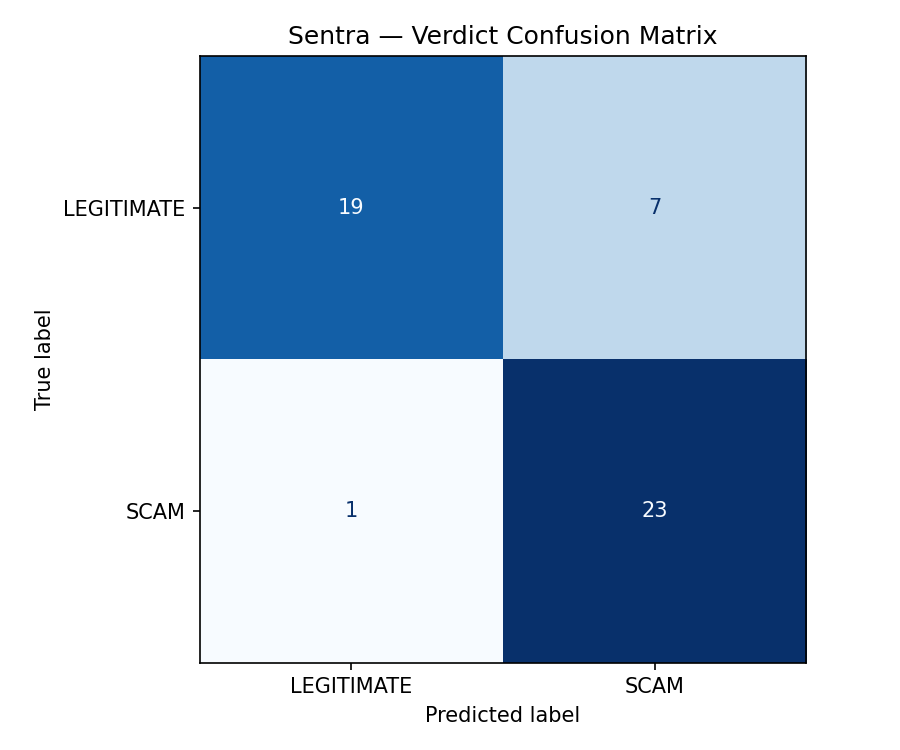

In [ ]:
# ── Cell 13: Display Confusion Matrix Inline ──────────────────────────────────
import os
from IPython.display import Image, display

if os.path.exists("confusion_matrix.png"):
    display(Image("confusion_matrix.png"))
else:
    print("confusion_matrix.png not found — run Cell 12 first.")

In [ ]:
# ── Cell 14: Download Output Files ────────────────────────────────────────────
import os, shutil
from google.colab import files

# Download confusion matrix
if os.path.exists("confusion_matrix.png"):
    files.download("confusion_matrix.png")
    print("✓ confusion_matrix.png downloading...")
else:
    print("confusion_matrix.png not found.")

# If Drive was NOT mounted, zip and download checkpoints
if not MOUNT_DRIVE:
    checkpoint_dir = os.path.join(OUTPUT_BASE)
    if os.path.exists(checkpoint_dir):
        print("\nZipping checkpoints (Drive not mounted)...")
        shutil.make_archive("sentra-checkpoints", "zip", checkpoint_dir)
        files.download("sentra-checkpoints.zip")
        print("✓ sentra-checkpoints.zip downloading...")
    else:
        print("No checkpoint directory found.")
else:
    print(f"\n✓ Checkpoints already saved to Google Drive:")
    print(f"   {OUTPUT_BASE}")
    # List checkpoint dirs
    for item in sorted(os.listdir(OUTPUT_BASE)):
        print(f"   └── {item}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ confusion_matrix.png downloading...

✓ Checkpoints already saved to Google Drive:
   /content/drive/MyDrive/sentra-training
   └── sentra-utoledo-v2.0
